# GISAID Discrepancies

## Housekeeping

In [ ]:
# Housekeeping

import os
import glob 
import pandas as pd
import xml.etree.ElementTree as ET
import requests
import time
import numpy as np
import dateutil 
from datetime import datetime
from collections import defaultdict 
import matplotlib.pyplot as plt

# Function to get partial isolate IDs (e.g. 24-001-000001-original -> 001-000001)
def partial_isolate(id):

    partial = id.replace("_", "-") # [-1] # If 25_, get the last bit
    partial = partial.replace("-original", "") # If -original suffix, remove
    partial = partial.replace("G", "-0") # If 25G, fix
    digits = partial.split("-")
    # Build partial isolates
    isolate = ""
    # other = ""
    for d in digits:
        # print(d)
        if len(d) == 2 and d.isnumeric(): # The 25 bit
            # isolate = d + "-"
            pass
        if len(d) == 6 and d.isnumeric(): # If it's just digits and not one of those weird isolates
            isolate = d + "-"
        if len(d) == 3 and d.isnumeric():
            isolate = isolate + d
        # elif d.isnumeric() == False: # If it's a weird isolate
        #     other = d + "-"
        # else: 
        #     other = partial 
    # Now add to list to check in Andersen files without doing wild for loops
    if len(isolate) == 10: # If this is a correctly formatted isolate
        # isolates.append(isolate)
        # All headers are followed by sequences
        partial_isolate = isolate
    else: # If this is some other isolate
        partial_isolate = partial

    return partial_isolate

### Downloading GISAID data

In [2]:
os.chdir("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/GISAID/downloads/2021-11-01--2025-06-13_Antarctica_North_America_South_America/")

gisaid_jun_13_2025 = pd.DataFrame()

for dirpath, dirs, files in os.walk("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/GISAID/downloads/2021-11-01--2025-06-13_Antarctica_North_America_South_America/"):
    for file in files:
        file_name = os.path.join(dirpath, file)
        if ".xls" in file_name:
            df = pd.read_excel(file_name)
            gisaid_jun_13_2025 = pd.concat([gisaid_jun_13_2025, df])
    break 

print(gisaid_jun_13_2025)

gisaid_jun_13_2025["Submission_Date"] = gisaid_jun_13_2025["Submission_Date"].apply(lambda x: dateutil.parser.parse(x))
gisaid_jun_13_2025["Collection_Date"] = gisaid_jun_13_2025["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

# gisaid_jun_13_2025 = gisaid_jun_13_2025[(gisaid_jun_13_2025["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (gisaid_jun_13_2025["Submission_Date"] <= dateutil.parser.parse("04/14/2025"))]
gisaid_jun_13_2025["Isolate"] = gisaid_jun_13_2025["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# gisaid_feb_20_2026["Isolate_gisaid"] = gisaid_feb_20_2026["Isolate"]
# gisaid_feb_20_2026["Publication"]
gisaid_jun_13_2025["Geo_Location_Specific"] = gisaid_jun_13_2025["Location"].apply(lambda x: x.split(" / ")[-1] if "United States" in x else x.split(" / ")[1] if len(x.split(" / ")) > 1 else x)
gisaid_jun_13_2025["Partial"] = gisaid_jun_13_2025["Isolate"].apply(partial_isolate)
print(gisaid_jun_13_2025.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])

            Isolate_Id                                     PB2 Segment_Id  \
0     EPI_ISL_16102933  EPI2243880|PB2_A/goose/Idaho/22-012047-001-ori...   
1     EPI_ISL_11971496  EPI2017172|Seq1 [organism=Influenza A virus](A...   
2     EPI_ISL_16173525        EPI2246894|A/Snow Goose/SK/FAV-0216-06/2022   
3     EPI_ISL_16172175        EPI2246886|A/Snow Goose/SK/FAV-0216-02/2022   
4     EPI_ISL_16171530        EPI2246877|A/Snow Goose/SK/FAV-0216-01/2022   
...                ...                                                ...   
1645  EPI_ISL_19705414  EPI3885044|A/dairy cow/California/001172-001/2...   
1646  EPI_ISL_19705413     EPI3885036|A/dairy cow/USA/001175-001/2025_PB2   
1647  EPI_ISL_19705412     EPI3885028|A/dairy cow/USA/001182-001/2025_PB2   
1648  EPI_ISL_19705411     EPI3885020|A/dairy cow/USA/001182-003/2025_PB2   
1649  EPI_ISL_19705410     EPI3885012|A/dairy cow/USA/000593-001/2025_PB2   

                                         PB1 Segment_Id  \
0     EPI2243881

### Downloading GenBank data

In [3]:
os.chdir("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/")

gisaid_feb_20_2026 = pd.DataFrame()
for dirpath, dirs, files in os.walk("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/GISAID/downloads/2021-11-01--2026-02-20_Antarctica_North_America_South_America/"):
    for file in files:
        file_name = os.path.join(dirpath, file)
        if ".xls" in file_name:
            df = pd.read_excel(file_name)
            gisaid_feb_20_2026 = pd.concat([gisaid_feb_20_2026, df])
    break 
# gisaid_apr_14_2025 = pd.read_csv("GISAID_submission_dates_02-14-2022--12-26-2024_accessed_04-14-2025.csv")
genbank_feb_20_2026 = pd.read_csv("NCBI_Virus/downloads/11-01-2021--02-20-2026_Antarctica_North_America_South_America/sequences.csv")
# genbank_apr_14_2025 = pd.read_csv("GenBank_submission_dates_02-14-2022--12-26-2024_accessed_04-14-2025.csv")
genbank_jun_13_2025 = pd.read_csv("NCBI_Virus/downloads/11-01-2021--06-13-2025_Antarctica_North_America_South_America_preprint/sequences.csv")

In [4]:
# gisaid_apr_14_2025["Submission_Date"] = gisaid_apr_14_2025["Submission_Date"].apply(lambda x: dateutil.parser.parse(x))
# gisaid_apr_14_2025["Collection_Date"] = gisaid_apr_14_2025["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

# gisaid_apr_14_2025 = gisaid_apr_14_2025[(gisaid_apr_14_2025["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (gisaid_apr_14_2025["Submission_Date"] <= dateutil.parser.parse("04/14/2025"))]
# gisaid_apr_14_2025["Isolate"] = gisaid_apr_14_2025["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# gisaid_apr_14_2025["Authors"] = gisaid_apr_14_2025["Authors"].apply(lambda x: x.split(", ")[0] if x==x else x)
# print(gisaid_apr_14_2025.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name", "Isolate"]])

In [5]:
gisaid_feb_20_2026["Submission_Date"] = gisaid_feb_20_2026["Submission_Date"].apply(lambda x: dateutil.parser.parse(x))
gisaid_feb_20_2026["Collection_Date"] = gisaid_feb_20_2026["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

gisaid_feb_20_2026 = gisaid_feb_20_2026[(gisaid_feb_20_2026["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (gisaid_feb_20_2026["Submission_Date"] <= dateutil.parser.parse("06/13/2025"))]
gisaid_feb_20_2026["Isolate"] = gisaid_feb_20_2026["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# gisaid_feb_20_2026["Isolate_gisaid"] = gisaid_feb_20_2026["Isolate"]
# gisaid_feb_20_2026["Publication"]
gisaid_feb_20_2026["Geo_Location_Specific"] = gisaid_feb_20_2026["Location"].apply(lambda x: x.split(" / ")[-1] if "United States" in x else x.split(" / ")[1] if len(x.split(" / ")) > 1 else x)
gisaid_feb_20_2026["Partial"] = gisaid_feb_20_2026["Isolate"].apply(partial_isolate)
print(gisaid_feb_20_2026.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])
# print(gisaid_feb_20_2026[gisaid_feb_20_2026["Submission_Date"] > dateutil.parser.parse("01/01/2025")])

     Submission_Date                                       Isolate_Name
770       2022-02-14    A/American wigeon/North Carolina/AH0182517/2022
769       2022-02-14            A/mallard/North Carolina/AH0182886/2022
768       2022-02-14   A/northern pintail/North Carolina/AH0182892/2022
767       2022-02-14            A/gadwall/North Carolina/AH0182894/2022
766       2022-02-14  A/northern shoveler/North Carolina/AH0182913/2022
...              ...                                                ...
3014      2025-06-11                    A/dairy cow/USA/016724-001/2025
3015      2025-06-11                    A/dairy cow/USA/016724-003/2025
3013      2025-06-11                    A/dairy cow/USA/016596-001/2025
3026      2025-06-11             A/dairy cow/California/016317-005/2025
1721      2025-06-12                        A/cat/New York/UIUC-01/2025

[17775 rows x 2 columns]


In [7]:
genbank_jun_13_2025["Submission_Date"] = genbank_jun_13_2025["Release_Date"].apply(lambda x: dateutil.parser.parse(x))
genbank_jun_13_2025["Collection_Date"] = genbank_jun_13_2025["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

# genbank_jun_13_2025 = genbank_jun_13_2025[(genbank_jun_13_2025["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (genbank_jun_13_2025["Submission_Date"] <= dateutil.parser.parse("04/14/2025"))]
genbank_jun_13_2025["Isolate_Name"] = genbank_jun_13_2025["GenBank_Title"].apply(lambda x: x.split("(")[1])
genbank_jun_13_2025["Isolate"] = genbank_jun_13_2025["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# genbank_feb_20_2026["Isolate_genbank"] = genbank_feb_20_2026["Isolate"]
genbank_jun_13_2025["Authors"] = genbank_jun_13_2025["Submitters"].apply(lambda x: x.split(" (")[0])
print(genbank_jun_13_2025.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])

      Submission_Date                                   Isolate_Name
83496      2021-11-01              A/chicken/Veracruz/28159-398/1995
83223      2021-11-01               A/chicken/Guatemala/45511-4/2000
83224      2021-11-01               A/chicken/Guatemala/45511-4/2000
83225      2021-11-01               A/chicken/Guatemala/45511-5/2000
83226      2021-11-01               A/chicken/Guatemala/45511-5/2000
...               ...                                            ...
4          2025-06-01  A/feline/San Bernardino County/297271-24/2024
3          2025-06-01  A/feline/San Bernardino County/297271-24/2024
2          2025-06-01  A/feline/San Bernardino County/297271-24/2024
1          2025-06-01  A/feline/San Bernardino County/297271-24/2024
0          2025-06-01  A/feline/San Bernardino County/297271-24/2024

[83497 rows x 2 columns]


In [8]:
genbank_feb_20_2026["Submission_Date"] = genbank_feb_20_2026["Release_Date"].apply(lambda x: dateutil.parser.parse(x))
genbank_feb_20_2026["Collection_Date"] = genbank_feb_20_2026["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

genbank_feb_20_2026 = genbank_feb_20_2026[(genbank_feb_20_2026["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (genbank_feb_20_2026["Submission_Date"] <= dateutil.parser.parse("06/13/2025"))]
genbank_feb_20_2026["Isolate_Name"] = genbank_feb_20_2026["GenBank_Title"].apply(lambda x: x.split("(")[1])
genbank_feb_20_2026["Isolate"] = genbank_feb_20_2026["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# genbank_feb_20_2026["Isolate_genbank"] = genbank_feb_20_2026["Isolate"]
# genbank_feb_20_2026["Authors"] = genbank_feb_20_2026["Submitters"] #.apply(lambda x: x.split(" (")[0])
genbank_feb_20_2026["Partial"] = genbank_feb_20_2026["Isolate"].apply(partial_isolate)
genbank_feb_20_2026["Geo_Location_Specific"] = genbank_feb_20_2026["Geo_Location"].apply(lambda x: x.split(": ")[-1] if "USA" not in x else genbank_feb_20_2026[genbank_feb_20_2026["Geo_Location"] == x]["USA"].values[0])
print(genbank_feb_20_2026.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])

       Submission_Date                                   Isolate_Name
143516      2021-11-01              A/chicken/Veracruz/28159-398/1995
143243      2021-11-01               A/chicken/Guatemala/45511-4/2000
143244      2021-11-01               A/chicken/Guatemala/45511-4/2000
143245      2021-11-01               A/chicken/Guatemala/45511-5/2000
143246      2021-11-01               A/chicken/Guatemala/45511-5/2000
...                ...                                            ...
59859       2025-06-01  A/feline/San Bernardino County/297271-24/2024
59858       2025-06-01  A/feline/San Bernardino County/297271-24/2024
59857       2025-06-01  A/feline/San Bernardino County/297271-24/2024
59856       2025-06-01  A/feline/San Bernardino County/297271-24/2024
59855       2025-06-01  A/feline/San Bernardino County/297271-24/2024

[83662 rows x 2 columns]


In [9]:
genbank_gisaid_common = genbank_feb_20_2026.merge(gisaid_feb_20_2026, on="Isolate", suffixes=["_genbank", "_gisaid"])
print(genbank_gisaid_common)

        Accession GenBank_RefSeq         Assembly SRA_Accession BioSample  \
0      PV576479.1        GenBank  GCA_050792345.1           NaN       NaN   
1      PV576480.1        GenBank  GCA_050792345.1           NaN       NaN   
2      PV576481.1        GenBank  GCA_050792345.1           NaN       NaN   
3      PV576482.1        GenBank  GCA_050792345.1           NaN       NaN   
4      PV576483.1        GenBank  GCA_050792345.1           NaN       NaN   
...           ...            ...              ...           ...       ...   
10986  OP221403.1        GenBank  GCA_039270135.1           NaN       NaN   
10987  OP221404.1        GenBank  GCA_039270135.1           NaN       NaN   
10988  OP222196.1        GenBank  GCA_039271695.1           NaN       NaN   
10989  OP222197.1        GenBank  GCA_039270135.1           NaN       NaN   
10990  OP222198.1        GenBank  GCA_039272365.1           NaN       NaN   

        BioProject      Organism_Name                         Species  \
0 

In [27]:
genbank_gisaid_uncommon = genbank_feb_20_2026.merge(gisaid_feb_20_2026, on=["Collection_Date", "Submission_Date", "Partial"], suffixes=["_genbank", "_gisaid"])
genbank_gisaid_uncommon["Year"] = genbank_gisaid_uncommon["Collection_Date"].apply(lambda x: x.year)

print(genbank_gisaid_uncommon) #[genbank_gisaid_uncommon["Year"] == "2025"]))


       Accession GenBank_RefSeq         Assembly SRA_Accession     BioSample  \
0     PV709298.1        GenBank  GCA_050792325.1   SRR33369832  SAMN48199889   
1     PV709299.1        GenBank  GCA_050792325.1   SRR33369832  SAMN48199889   
2     PV709300.1        GenBank  GCA_050792325.1   SRR33369832  SAMN48199889   
3     PV709301.1        GenBank  GCA_050792325.1   SRR33369832  SAMN48199889   
4     PV709302.1        GenBank  GCA_050792325.1   SRR33369832  SAMN48199889   
...          ...            ...              ...           ...           ...   
6474  PP755888.1        GenBank  GCA_039463955.1   SRR28752613  SAMN41019241   
6475  PP755889.1        GenBank  GCA_039463955.1   SRR28752613  SAMN41019241   
6476  PP755890.1        GenBank  GCA_039463955.1   SRR28752613  SAMN41019241   
6477  PP755891.1        GenBank  GCA_039463955.1   SRR28752613  SAMN41019241   
6478  PP755892.1        GenBank  GCA_039463955.1   SRR28752613  SAMN41019241   

        BioProject      Organism_Name  

In [ ]:
genbank_gisaid_uncommon_partials = genbank_feb_20_2026.merge(gisaid_feb_20_2026, on=["Collection_Date", "Host"], suffixes=["_genbank", "_gisaid"])
print(genbank_gisaid_uncommon_partials.columns)
print(genbank_gisaid_uncommon_partials[(genbank_gisaid_uncommon_partials["Partial_genbank"] != genbank_gisaid_uncommon_partials["Partial_gisaid"]) & (genbank_gisaid_uncommon_partials["Country"] == genbank_gisaid_uncommon_partials["Geo_Location_Specific_gisaid"])]) #[["Partial_gisaid", "Partial_genbank", "Collection_Date", "Host", "Geo_Location_Specific_gisaid", "Geo_Location_Specific_genbank", "Submitters", "Publication"]])

os.chdir("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Presentations/")
# genbank_gisaid_uncommon_partials[(genbank_gisaid_uncommon_partials["Partial_genbank"] != genbank_gisaid_uncommon_partials["Partial_gisaid"]) & (genbank_gisaid_uncommon_partials["Country"] == genbank_gisaid_uncommon_partials["Geo_Location_Specific_gisaid"])].to_csv("genbank_gisaid_uncommon_partials_same_geo.csv")

Index(['Accession', 'GenBank_RefSeq', 'Assembly', 'SRA_Accession', 'BioSample',
       'BioProject', 'Organism_Name', 'Species', 'Genus', 'Family',
       'Genotype_genbank', 'Isolate_genbank', 'Segment', 'GenBank_Title',
       'Length', 'Nuc_Completeness', 'Geo_Location', 'Country', 'USA', 'Host',
       'Tissue_Specimen_Source', 'Submitters', 'Organization', 'Org_location',
       'Publications', 'Collection_Date', 'Release_Date', 'Molecule_type',
       'Submission_Date_genbank', 'Isolate_Name_genbank', 'Partial_genbank',
       'Geo_Location_Specific_genbank', 'Isolate_Id', 'PB2 Segment_Id',
       'PB1 Segment_Id', 'PA Segment_Id', 'HA Segment_Id', 'NP Segment_Id',
       'NA Segment_Id', 'MP Segment_Id', 'NS Segment_Id', 'HE Segment_Id',
       'P3 Segment_Id', 'Isolate_Name_gisaid', 'Subtype', 'Genotype_gisaid',
       'Lineage', 'Clade', 'Pathogenicity', 'Passage_History', 'Location',
       'Isolate_Submitter', 'Submitting_Sample_Id', 'Publication',
       'Originating_Sample

In [11]:
gisaid_time = gisaid_jun_13_2025.merge(gisaid_feb_20_2026, on="Isolate_Id", suffixes=["_old", "_new"])
print(gisaid_time)

             Isolate_Id                                 PB2 Segment_Id_old  \
0      EPI_ISL_16102933  EPI2243880|PB2_A/goose/Idaho/22-012047-001-ori...   
1      EPI_ISL_11971496  EPI2017172|Seq1 [organism=Influenza A virus](A...   
2      EPI_ISL_16173525        EPI2246894|A/Snow Goose/SK/FAV-0216-06/2022   
3      EPI_ISL_16172175        EPI2246886|A/Snow Goose/SK/FAV-0216-02/2022   
4      EPI_ISL_16171530        EPI2246877|A/Snow Goose/SK/FAV-0216-01/2022   
...                 ...                                                ...   
17677  EPI_ISL_19705414  EPI3885044|A/dairy cow/California/001172-001/2...   
17678  EPI_ISL_19705413     EPI3885036|A/dairy cow/USA/001175-001/2025_PB2   
17679  EPI_ISL_19705412     EPI3885028|A/dairy cow/USA/001182-001/2025_PB2   
17680  EPI_ISL_19705411     EPI3885020|A/dairy cow/USA/001182-003/2025_PB2   
17681  EPI_ISL_19705410     EPI3885012|A/dairy cow/USA/000593-001/2025_PB2   

                                      PB1 Segment_Id_old  \
0  

## Differences between GenBank and GISAID

### Isolates

All of the following have the same isolate "root", but different complete isolates. 

Isolate discrepancy examples:
- Sometimes the beginning hyphen in an isolate will be changed to an underscore (24-014001-004 -> 24_014001-004)
- Sometimes an appended "-original" at the end of the isolate will disappear (24-014001-004-original -> 24-014001-004)
- Sometimes the last two digits of a year at the beginning of an isolate will disappear (24-009038-001 -> 009038-001)
- Sometimes a repeated isolate will have the "-repeat2" appendage changed to "-R2" (24-015840-001-original-repeat2 -> 24_015840-001-R2)
- Sometimes, despite the same authors, collection date, location, and host, the isolate IDs are completely different (CEIRR-293 -> TN22-293)

                     Isolate_genbank    Isolate_gisaid  \
0     24-036138-001-original-repeat2  24_036138-001-R2   
1     24-036138-001-original-repeat2  24_036138-001-R2   
2     24-036138-001-original-repeat2  24_036138-001-R2   
3     24-036138-001-original-repeat2  24_036138-001-R2   
4     24-036138-001-original-repeat2  24_036138-001-R2   
...                              ...               ...   
6474                   24-009109-002     24_009109-002   
6475                   24-009109-002     24_009109-002   
6476                   24-009109-002     24_009109-002   
6477                   24-009109-002     24_009109-002   
6478                   24-009109-002     24_009109-002   

                                 Isolate_Name_genbank  \
0     A/cattle/CA/24-036138-001-original-repeat2/2024   
1     A/cattle/CA/24-036138-001-original-repeat2/2024   
2     A/cattle/CA/24-036138-001-original-repeat2/2024   
3     A/cattle/CA/24-036138-001-original-repeat2/2024   
4     A/cattle/CA/

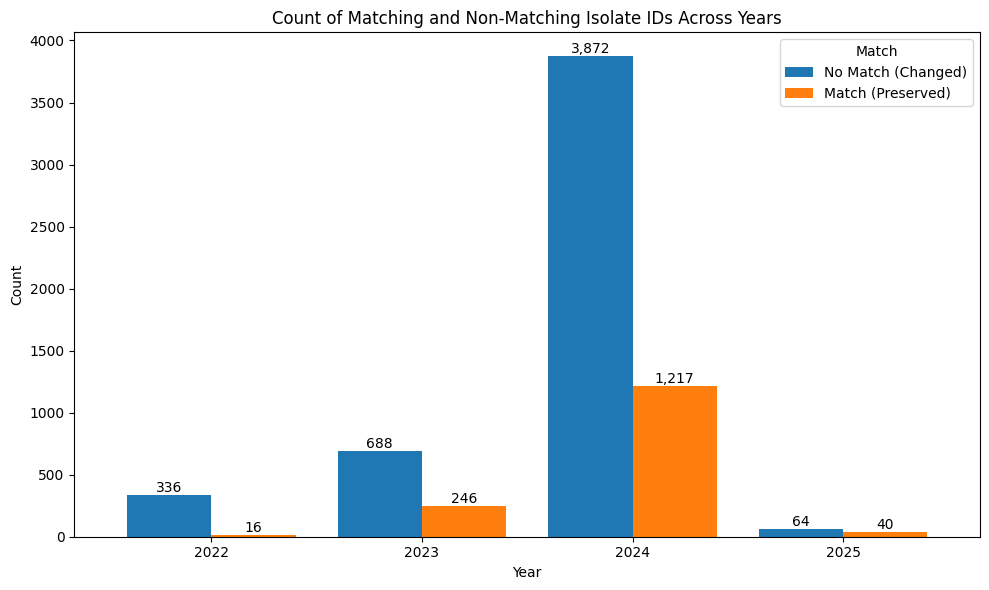

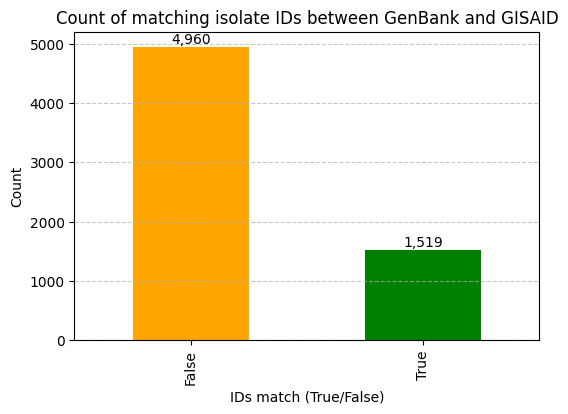

In [12]:
print(genbank_gisaid_uncommon[genbank_gisaid_uncommon["Isolate_genbank"] != genbank_gisaid_uncommon["Isolate_gisaid"]][["Isolate_genbank", "Isolate_gisaid", "Isolate_Name_genbank", "Isolate_Name_gisaid"]])

genbank_gisaid_uncommon["Match"] = (genbank_gisaid_uncommon["Isolate_genbank"] == genbank_gisaid_uncommon["Isolate_gisaid"])


match_counts = genbank_gisaid_uncommon.groupby(["Year", "Match"]).size().rename('Count').reset_index()
df_plot = match_counts.pivot_table(index='Year', columns='Match', values='Count', fill_value=0)

print(df_plot)

# Plot the grouped bar chart using pandas built-in plot function
ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.8)

# Customize the plot
plt.title('Count of Matching and Non-Matching Isolate IDs Across Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Match', labels=['No Match (Changed)', 'Match (Preserved)']) # Add a legend with meaningful labels
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Display the plot
plt.show()

# ax = match_counts.plot(kind='bar', figsize=(10, 6))

# # Customize the plot using matplotlib functions
# plt.title('Number of Identical Isolate IDs Between GenBank and GISAID Across Years')
# plt.xlabel('Year')
# plt.ylabel('Count of Identical Isolate IDs')
# plt.xticks(rotation=45) # Rotate x-axis labels for better readability
# plt.grid(axis='y', linestyle='--')
# plt.tight_layout() # Adjust layout to make room for x-axis labels
# plt.show()

match_counts = genbank_gisaid_uncommon["Match"].value_counts()

# plt.figure(figsize=(6, 4))

# Plotting the match counts
ax2 = match_counts.plot(kind='bar', color=['orange', 'green'], figsize=(6, 4))

for container in ax2.containers:
    ax2.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching isolate IDs between GenBank and GISAID')
plt.xlabel('IDs match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [13]:
print(genbank_gisaid_uncommon[genbank_gisaid_uncommon["Isolate_gisaid"] != genbank_gisaid_uncommon["Isolate_genbank"]][["Isolate_genbank", "Isolate_gisaid", "Isolate_Name_genbank", "Isolate_Name_gisaid"]][:50])

                   Isolate_genbank    Isolate_gisaid  \
0   24-036138-001-original-repeat2  24_036138-001-R2   
1   24-036138-001-original-repeat2  24_036138-001-R2   
2   24-036138-001-original-repeat2  24_036138-001-R2   
3   24-036138-001-original-repeat2  24_036138-001-R2   
4   24-036138-001-original-repeat2  24_036138-001-R2   
5   24-036138-001-original-repeat2  24_036138-001-R2   
6   24-036138-001-original-repeat2  24_036138-001-R2   
7   24-036138-001-original-repeat2  24_036138-001-R2   
8   24-036138-002-original-repeat2  24_036138-002-R2   
9   24-036138-002-original-repeat2  24_036138-002-R2   
10  24-036138-002-original-repeat2  24_036138-002-R2   
11  24-036138-002-original-repeat2  24_036138-002-R2   
12  24-036138-002-original-repeat2  24_036138-002-R2   
13  24-036138-002-original-repeat2  24_036138-002-R2   
14  24-036138-002-original-repeat2  24_036138-002-R2   
15  24-036138-002-original-repeat2  24_036138-002-R2   
16  24-036187-001-original-repeat2  24_036187-00

### Isolate Names

All of these share isolate IDs, but have different full isolate names. 

Isolate name discrepancy examples:
- GISAID sometimes cuts off or changes the specific type of animal to a general animal (snow goose -> goose, black vulture -> vulture, mallard -> duck, etc.)
- GISAID sometimes subtly changes the location name (Bio Bio -> Biobio, CHL -> Chile, etc.)
- GISAID sometimes changes the specific location to a more general location (Antofagasta -> Chile, etc.)
- Sometimes the isolate ids between genbank and gisaid are the same, but the isolate names are completely different (A/Missouri/121/2024 has the same isolate id as A/red-shouldered hawk/North Carolina/121/2022, etc.)

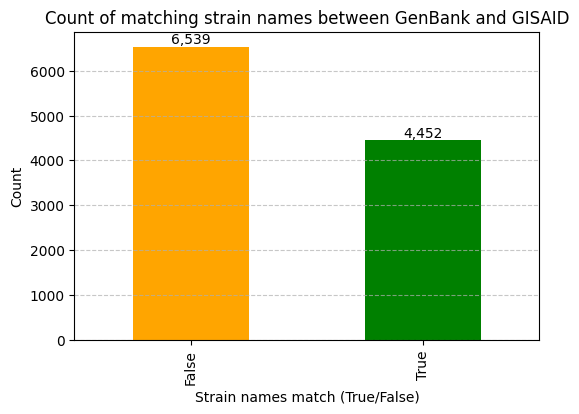

In [14]:
genbank_gisaid_common[genbank_gisaid_common["Isolate_Name_genbank"] != genbank_gisaid_common["Isolate_Name_gisaid"]][["Isolate_Name_genbank", "Isolate_Name_gisaid"]]

matches = (genbank_gisaid_common["Isolate_Name_genbank"] == genbank_gisaid_common["Isolate_Name_gisaid"])

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['orange', 'green'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching strain names between GenBank and GISAID')
plt.xlabel('Strain names match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### Collection Dates

All of these share isolate IDs, but have different collection dates in the metadata. This occurs in (117/4955) entries of our sample.

Date discrepancy examples:
- GISAID sometimes changes the collection date to the beginning of the month (2022-12-26 -> 12-01-2022, etc.)
- GISAID sometimes changes the collection date to a completely different date (2024-03-08 -> 2024-02-26, etc.)
- GISAID sometimes changes the collection date, if unknown and year 2025-2026, to the first of the year (2025 -> 2025-01-01, etc.) (Not in this sample)

                              Isolate_Name_genbank  \
4729           A/Ross's goose/Kansas/W23-949A/2023   
4730           A/Ross's goose/Kansas/W23-949A/2023   
4731           A/Ross's goose/Kansas/W23-949A/2023   
4732           A/Ross's goose/Kansas/W23-949A/2023   
4956            A/chicken/Texas/24-009654-001/2024   
4957            A/chicken/Texas/24-009654-001/2024   
4958            A/chicken/Texas/24-009654-001/2024   
4959            A/chicken/Texas/24-009654-001/2024   
4960            A/chicken/Texas/24-009654-001/2024   
4961            A/chicken/Texas/24-009654-001/2024   
4962            A/chicken/Texas/24-009654-001/2024   
4963            A/chicken/Texas/24-009654-001/2024   
4980           A/goat/Minnesota/24-007234-059/2024   
4981           A/goat/Minnesota/24-007234-059/2024   
4982           A/goat/Minnesota/24-007234-059/2024   
4983           A/goat/Minnesota/24-007234-059/2024   
4984           A/goat/Minnesota/24-007234-059/2024   
4985           A/goat/Minnes

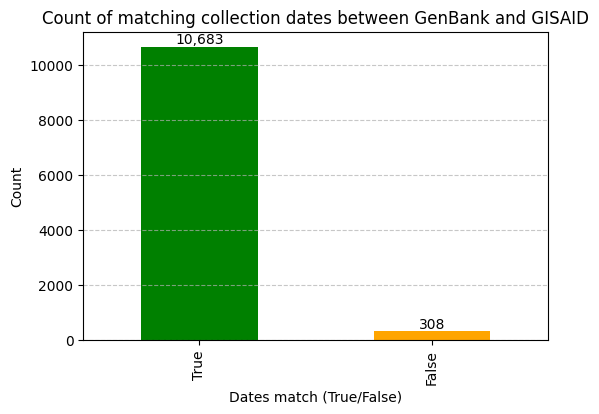

In [15]:
print(genbank_gisaid_common[genbank_gisaid_common["Collection_Date_gisaid"] != genbank_gisaid_common["Collection_Date_genbank"]][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Collection_Date_genbank", "Collection_Date_gisaid"]][-100:-50])

matches = (genbank_gisaid_common["Collection_Date_genbank"] == genbank_gisaid_common["Collection_Date_gisaid"])

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['green', 'orange'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching collection dates between GenBank and GISAID')
plt.xlabel('Dates match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### Host Names

All of these share isolate IDs, but have different host names in the metadata. This occurs in the **majority** (4811/4955) of our sample, though much of this can be explained by GISAID opting for the common name over the scientific name of each species.

Host name discrepancy examples:
- GISAID often just has the word "Host" in place of a host name (Leucophaeus modestus/gray gull -> Host)
- GISAID often, instead of using the specific species, has the host type in place of a host name (Theristicus caudatus/buff-necked ibis -> Avian)

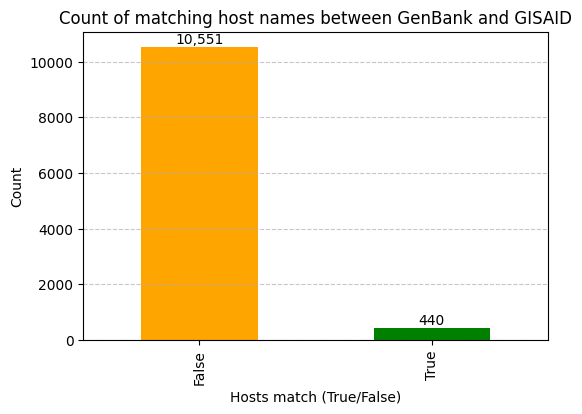

In [16]:
genbank_gisaid_common[genbank_gisaid_common["Host_gisaid"] != genbank_gisaid_common["Host_genbank"]][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Host_genbank", "Host_gisaid"]]

matches = (genbank_gisaid_common["Host_genbank"] == genbank_gisaid_common["Host_gisaid"])

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['orange', 'green'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching host names between GenBank and GISAID')
plt.xlabel('Hosts match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### Locations

                                Isolate_Name_genbank  \
208              A/swine/Kansas/ExpPig61-OP1DPI/2024   
209              A/swine/Kansas/ExpPig61-OP1DPI/2024   
210              A/swine/Kansas/ExpPig61-OP1DPI/2024   
211              A/swine/Kansas/ExpPig61-OP1DPI/2024   
212              A/swine/Kansas/ExpPig61-OP1DPI/2024   
213              A/swine/Kansas/ExpPig61-OP1DPI/2024   
214              A/swine/Kansas/ExpPig61-OP1DPI/2024   
215              A/swine/Kansas/ExpPig61-OP1DPI/2024   
216        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
217        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
218        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
219        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
220        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
221        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
222        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
223        A/bovine/Kansas/Inoc-TX-24-029328-01/2024   
224  A/American green-winged teal/USA/IZ24_0776/

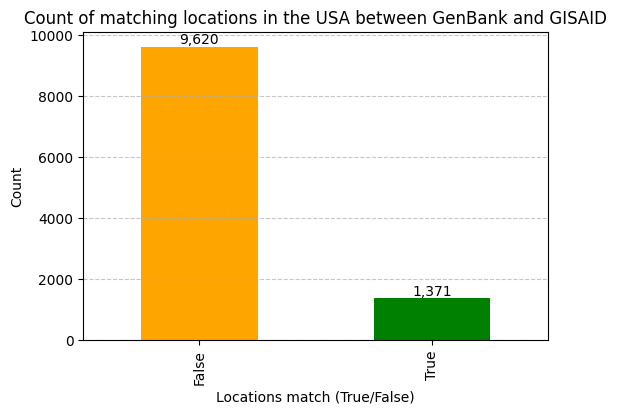

In [17]:
# print(genbank_gisaid_common[genbank_gisaid_common["Geo_Location_Specific_gisaid"] != genbank_gisaid_common["Geo_Location_Specific_genbank"]][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Geo_Location_Specific_genbank", "Geo_Location_Specific_gisaid"]])
print(genbank_gisaid_common[(genbank_gisaid_common["Geo_Location_Specific_gisaid"] != genbank_gisaid_common["USA"]) & (genbank_gisaid_common["Country"] == "USA")][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Geo_Location_Specific_genbank", "Geo_Location_Specific_gisaid"]][200:250]) # 

matches = (genbank_gisaid_common["Geo_Location_Specific_genbank"] == genbank_gisaid_common["Geo_Location_Specific_gisaid"]) 

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['orange', 'green'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching locations in the USA between GenBank and GISAID')
plt.xlabel('Locations match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## GISAID Metadata Updates

Sometimes, GISAID silently updates or changes metadata without warning.

GISAID metadata change examples:
- Sometimes GISAID appends or removes the last two digits of the year to the isolate ID, changing the strain name altogether (24_035820-001 -> 024710-001)
    - The last two digits of the year may be appended with an underscore, or a hyphen, making parsing the "root" isolate ID difficult (24-000001-001 vs. 24_000001-001)
    - Some isolate IDs include an "-original" appendage, making de-duplication between databases difficult (24-000001-001-original vs. 24-000001-001)
    - Some isolate IDs include an "-R2" or "-repeat2" appendage, making de-duplication between databases difficult (24-000001-001-R2 or 24-000001-001-original-repeat2 vs. 24-000001-001)
- Sometimes dates change completely without warning (2024-02-27 -> 2024-08-26)
- Sometimes dates are egregiously incorrect, both in the isolate name and the metadata, and must be updated later (A/bald eagle/Alaska/22-035250-002/1905, 1905-07-14 -> A/bald eagle/Alaska/22-035250-002/2022, 2022-02-27) 
- Genotypes may change without warning, or a genotype may be changed from an assigned to genotype to "Not assigned", even when the genotype is still current (B3.13 -> Notassigned)
    - Genotypes disappear in (135/6385) entries in our sample.
    - Rarely will a genotype be updated from "Not assigned" to an assigned genotype
- There is no mechanism in GISAID to know when metadata is updated -- meaning that all data must be downloaded each time just in case metadata (or the strain name altogether) has changed (A/dairy cow/USA/24_024710-001/2024 -> A/dairy cow/California/024710-001/2024)
    - While an "update date" column exists in the metadata, it mostly seems to only match the submission date -- otherwise, the update is either unclear or a removal of a previously assigned genotype without a replacement (B3.2 -> Notassigned)

                         Isolate_Name_old  \
11572  A/dairy cow/USA/24_030591-001/2024   
11573  A/dairy cow/USA/24_030592-002/2024   
11601  A/dairy cow/USA/24_030166-001/2024   
11616  A/dairy cow/USA/24_031290-001/2024   
11617  A/dairy cow/USA/24_031293-001/2024   
...                                   ...   
13937  A/dairy cow/USA/24_034429-001/2024   
13943  A/dairy cow/USA/24_034654-001/2024   
13949  A/dairy cow/USA/24_034694-001/2024   
13950  A/dairy cow/USA/24_034694-003/2024   
13951  A/dairy cow/USA/24_034695-001/2024   

                             Isolate_Name_new    Isolate_old Isolate_new  
11572  A/dairy cow/California/030591-001/2024  24_030591-001  030591-001  
11573  A/dairy cow/California/030592-002/2024  24_030592-002  030592-002  
11601  A/dairy cow/California/030166-001/2024  24_030166-001  030166-001  
11616  A/dairy cow/California/031290-001/2024  24_031290-001  031290-001  
11617  A/dairy cow/California/031293-001/2024  24_031293-001  031293-001  
...      

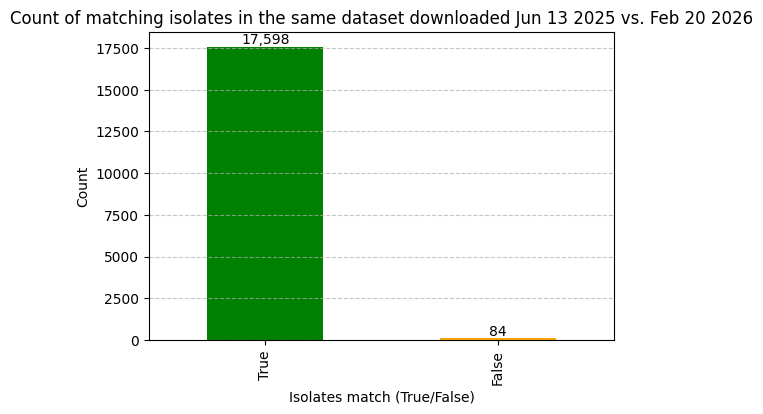

In [18]:
print(gisaid_time[gisaid_time["Isolate_old"] != gisaid_time["Isolate_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new"]])

matches = (gisaid_time["Isolate_old"] == gisaid_time["Isolate_new"]) 

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['green', 'orange'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching isolates in the same dataset downloaded Jun 13 2025 vs. Feb 20 2026')
plt.xlabel('Isolates match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

                         Isolate_Name_old  \
2244      A/dairy cow/USA/004637-005/2025   
2245      A/dairy cow/USA/004637-006/2025   
2265   A/canada goose/USA/004847-003/2025   
2273   A/canada goose/USA/005136-001/2025   
2274   A/canada goose/USA/005306-001/2025   
...                                   ...   
17661     A/dairy cow/USA/001170-004/2025   
17663     A/dairy cow/USA/001175-002/2025   
17664     A/dairy cow/USA/001177-001/2025   
17676     A/dairy cow/USA/001121-001/2025   
17678     A/dairy cow/USA/001175-001/2025   

                                  Isolate_Name_new Isolate_old Isolate_new  \
2244        A/dairy cow/California/004637-005/2025  004637-005  004637-005   
2245        A/dairy cow/California/004637-006/2025  004637-006  004637-006   
2265        A/canada goose/Florida/004847-003/2025  004847-003  004847-003   
2273   A/canada goose/Pennsylvania/005136-001/2025  005136-001  005136-001   
2274       A/canada goose/New York/005306-001/2025  005306-001  00530

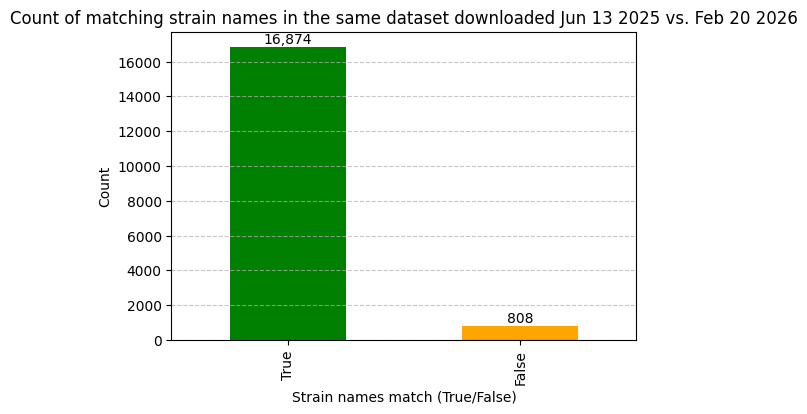

In [19]:
print(gisaid_time[gisaid_time["Isolate_Name_old"] != gisaid_time["Isolate_Name_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new", "Collection_Date_old", "Collection_Date_new"]])

matches = (gisaid_time["Isolate_Name_old"] == gisaid_time["Isolate_Name_new"]) 

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['green', 'orange'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching strain names in the same dataset downloaded Jun 13 2025 vs. Feb 20 2026')
plt.xlabel('Strain names match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

                         Isolate_Name_old  \
2265   A/canada goose/USA/004847-003/2025   
2273   A/canada goose/USA/005136-001/2025   
2274   A/canada goose/USA/005306-001/2025   
2284   A/canada goose/USA/005785-002/2025   
2451       A/barn owl/USA/005389-001/2025   
...                                   ...   
17584     A/dairy cow/USA/001731-005/2025   
17601     A/dairy cow/USA/001121-002/2025   
17663     A/dairy cow/USA/001175-002/2025   
17676     A/dairy cow/USA/001121-001/2025   
17678     A/dairy cow/USA/001175-001/2025   

                                  Isolate_Name_new Isolate_old Isolate_new  \
2265        A/canada goose/Florida/004847-003/2025  004847-003  004847-003   
2273   A/canada goose/Pennsylvania/005136-001/2025  005136-001  005136-001   
2274       A/canada goose/New York/005306-001/2025  005306-001  005306-001   
2284       A/canada goose/New York/005785-002/2025  005785-002  005785-002   
2451             A/barn owl/Nevada/005389-001/2025  005389-001  00538

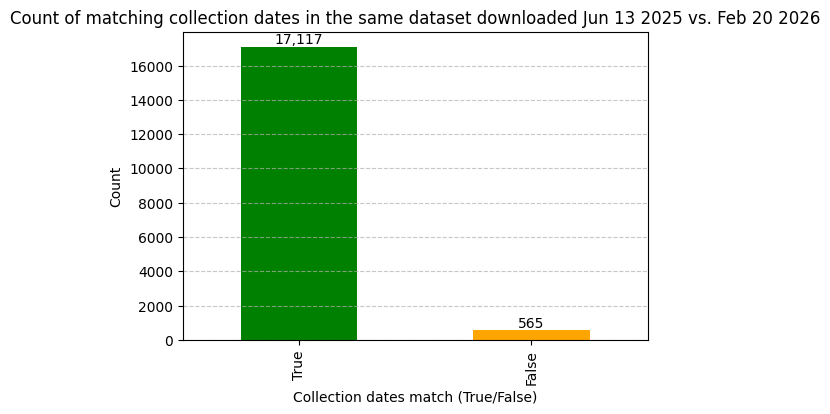

In [20]:
print(gisaid_time[gisaid_time["Collection_Date_old"] != gisaid_time["Collection_Date_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new", "Collection_Date_old", "Collection_Date_new"]])

matches = (gisaid_time["Collection_Date_old"] == gisaid_time["Collection_Date_new"]) 

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['green', 'orange'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching collection dates in the same dataset downloaded Jun 13 2025 vs. Feb 20 2026')
plt.xlabel('Collection dates match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

                                    Isolate_Name_old  \
694                    A/Pelican/Venezuela/Pel4/2022   
695                    A/Pelican/Venezuela/Pel3/2022   
862    A/Pelecanus occidentalis/Venezuela/Inf13/2022   
1101                   A/Pelican/Venezuela/Inf9/2022   
2265              A/canada goose/USA/004847-003/2025   
...                                              ...   
17584                A/dairy cow/USA/001731-005/2025   
17601                A/dairy cow/USA/001121-002/2025   
17663                A/dairy cow/USA/001175-002/2025   
17676                A/dairy cow/USA/001121-001/2025   
17678                A/dairy cow/USA/001175-001/2025   

                                    Isolate_Name_new Isolate_old Isolate_new  \
694                    A/Pelican/Venezuela/Pel4/2022        Pel4        Pel4   
695                    A/Pelican/Venezuela/Pel3/2022        Pel3        Pel3   
862    A/Pelecanus occidentalis/Venezuela/Inf13/2022       Inf13       Inf13   
1101   

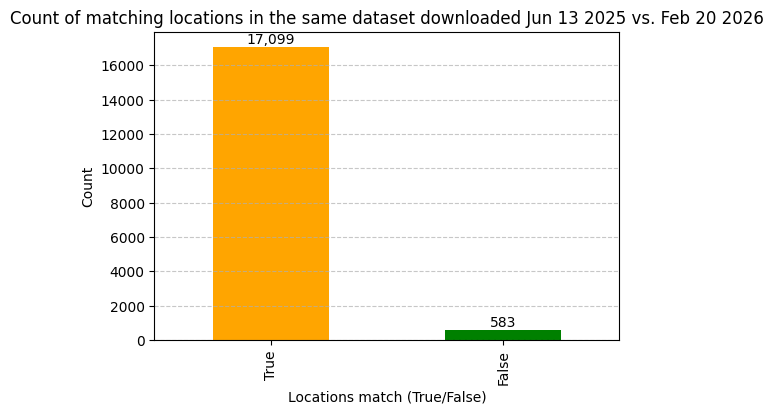

In [21]:
print(gisaid_time[gisaid_time["Location_old"] != gisaid_time["Location_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new","Location_old", "Location_new"]])

matches = (gisaid_time["Location_old"] == gisaid_time["Location_new"]) 

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['orange', 'green'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching locations in the same dataset downloaded Jun 13 2025 vs. Feb 20 2026')
plt.xlabel('Locations match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

                             Isolate_Name_old  \
689    A/Great Horned Owl/AB/FAV-0505-52/2022   
692                A/RT-Hawk/ON/FAV-0210/2022   
720             A/Chicken/AB/FAV-0438-02/2022   
722             A/Chicken/ON/FAV-0217-05/2022   
723            A/Chicken/ON/FAV-0208-144/2022   
...                                       ...   
17668         A/dairy cow/USA/000590-002/2025   
17671         A/dairy cow/USA/000591-001/2025   
17675         A/dairy cow/USA/001146-001/2025   
17677  A/dairy cow/California/001172-001/2025   
17679         A/dairy cow/USA/001182-001/2025   

                             Isolate_Name_new   Isolate_old   Isolate_new  \
689    A/Great Horned Owl/AB/FAV-0505-52/2022   FAV-0505-52   FAV-0505-52   
692                A/RT-Hawk/ON/FAV-0210/2022      FAV-0210      FAV-0210   
720             A/Chicken/AB/FAV-0438-02/2022   FAV-0438-02   FAV-0438-02   
722             A/Chicken/ON/FAV-0217-05/2022   FAV-0217-05   FAV-0217-05   
723            A/Chicken/O

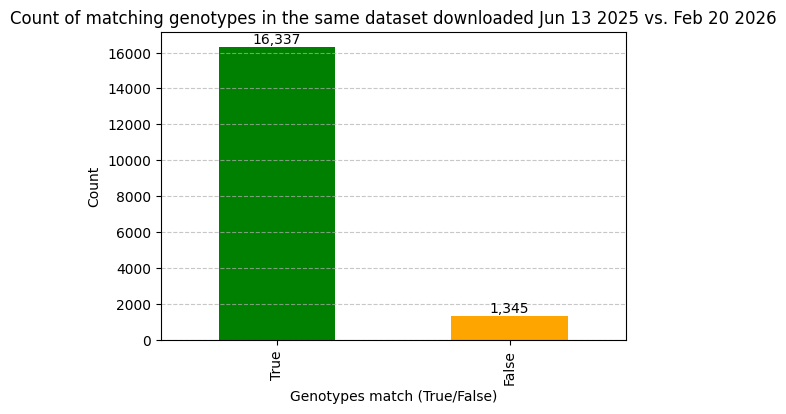

In [22]:
print(gisaid_time[gisaid_time["Genotype_old"] != gisaid_time["Genotype_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new","Genotype_old", "Genotype_new"]])
print(gisaid_time[(gisaid_time["Genotype_old"] != gisaid_time["Genotype_new"]) & (gisaid_time["Genotype_new"].str.contains("Notassigned"))][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new","Genotype_old", "Genotype_new"]])

matches = (gisaid_time["Genotype_old"] == gisaid_time["Genotype_new"]) 

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
ax = match_counts.plot(kind='bar', color=['green', 'orange'])

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Adding labels and a title
plt.title('Count of matching genotypes in the same dataset downloaded Jun 13 2025 vs. Feb 20 2026')
plt.xlabel('Genotypes match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

Match  False   True 
Year                
2021     0.0    26.0
2022    26.0  7201.0
2023   189.0  2356.0
2024   631.0  4186.0
2025   499.0  2567.0


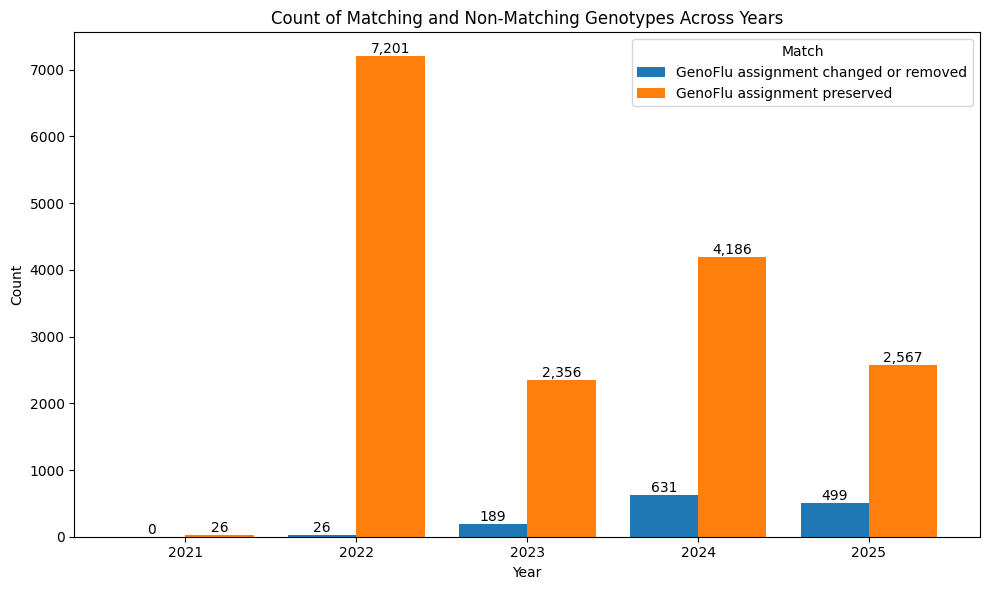

In [23]:
gisaid_time["Match"] = (gisaid_time["Genotype_old"] == gisaid_time["Genotype_new"])
gisaid_time["Year"] = gisaid_time["Collection_Date_new"].apply(lambda x: x.year)
gisaid_time = gisaid_time[gisaid_time["Year"] >= 2021]
match_counts = gisaid_time.groupby(["Year", "Match"]).size().rename('Count').reset_index()
df_plot = match_counts.pivot_table(index='Year', columns='Match', values='Count', fill_value=0)

print(df_plot)

# Plot the grouped bar chart using pandas built-in plot function
ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.8)

# Customize the plot
plt.title('Count of Matching and Non-Matching Genotypes Across Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Match', labels=['GenoFlu assignment changed or removed', 'GenoFlu assignment preserved']) # Add a legend with meaningful labels
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

# Display the plot
plt.show()

In [24]:
print(gisaid_time[gisaid_time["Update_Date_old"] != gisaid_time["Update_Date_new"]][["Isolate_Name_old", "Isolate_Name_new", "Update_Date_old", "Update_Date_new"]]) # All NaN


                             Isolate_Name_old  \
7            A/snow goose/Kansas/W22-260/2022   
9       A/snow goose/North Dakota/N22-05/2022   
12          A/snow goose/Kansas/W22-199C/2022   
13          A/snow goose/Kansas/W22-199E/2022   
14          A/snow goose/Kansas/W22-199B/2022   
...                                       ...   
17677  A/dairy cow/California/001172-001/2025   
17678         A/dairy cow/USA/001175-001/2025   
17679         A/dairy cow/USA/001182-001/2025   
17680         A/dairy cow/USA/001182-003/2025   
17681         A/dairy cow/USA/000593-001/2025   

                             Isolate_Name_new Update_Date_old Update_Date_new  
7            A/snow goose/Kansas/W22-260/2022             NaN             NaN  
9       A/snow goose/North Dakota/N22-05/2022             NaN             NaN  
12          A/snow goose/Kansas/W22-199C/2022             NaN             NaN  
13          A/snow goose/Kansas/W22-199E/2022             NaN             NaN  
14         

In [25]:
print(gisaid_time[(gisaid_time["Update_Date_old"] != gisaid_time["Submission_Date_old"]) & (gisaid_time["Update_Date_old"] == gisaid_time["Update_Date_old"])][["Isolate_Name_old", "Isolate_Name_new", "Update_Date_old", "Submission_Date_old", "Collection_Date_old", "Collection_Date_new", "Location_old", "Location_new", "Genotype_old", "Genotype_new", "Host_old", "Host_new"]])

                                    Isolate_Name_old  \
0                   A/goose/Idaho/22-012047-001/2022   
5                  A/snow goose/Kansas/W22-174B/2022   
6        A/lesser snow goose/North Dakota/ND-10/2022   
8                  A/snow goose/Kansas/W22-177B/2022   
10             A/snow goose/North Dakota/N22-04/2022   
...                                              ...   
13004                 A/Chicken/BC/FAV-0289-002/2024   
13123  A/kelp_gull/South Shetland Islands/10272/2024   
13815               A/British_Columbia/PHL-2032/2024   
14835                            A/Louisiana/12/2024   
14836                            A/Louisiana/12/2024   

                                  Isolate_Name_new Update_Date_old  \
0                 A/goose/Idaho/22-012047-001/2022      2022-12-18   
5                A/snow goose/Kansas/W22-174B/2022      2022-09-12   
6      A/lesser snow goose/North Dakota/ND-10/2022      2022-09-12   
8                A/snow goose/Kansas/W22-177B/2